# Ordered ATAC-to-RNA loading priors

This example uses ATAC loadings to inform RNA while respecting the order
$A_k\mid A_{<k}$ and $R_k\mid R_{<k},A$. There is no separately fitted reverse
RNA-to-ATAC conditional.

**Scope:** these conditionals define a valid joint prior, but the current
`cEBMF.iter_once()` implementation conditions on estimated parent loadings.
It omits downstream conditional-prior terms and parent uncertainty when
updating a loading. This notebook evaluates that conditional approximation;
it does not claim to fit the full joint posterior. See
`docs/source/ordered_loading_priors.rst` for the missing terms.

Run with the updated package and a fresh kernel. Defaults reproduce the CPU
diagnostic. All accuracy calculations compare each modality against its own
noiseless matrix. The optional shuffled-row control tests whether ATAC's cell
alignment helps RNA. Runtime is a few minutes on CPU.

In [8]:
import io
from contextlib import redirect_stdout

import matplotlib.pyplot as plt
import torch

import cebmf_torch
from cebmf_torch import cEBMF

device = torch.device("cpu")
torch.set_num_threads(1)
print("Package:", cebmf_torch.__file__)

Package: C:\Document\Serieux\Travail\python_work\package\cebmf_torch\src\cebmf_torch\__init__.py


## Reproduce the simulation

Rows are matched cells in both matrices. The four RNA profiles span three
block patterns, so a three-factor RNA reconstruction is sufficient. True
loadings and noiseless matrices are used for evaluation only.

In [9]:
N, P = 2000, 1000
torch.manual_seed(1)

F_ATAC = torch.zeros(P, 2)
F_ATAC[200:250, 0] = 1
F_ATAC[700:750, 1] = 1
L_ATAC = torch.stack(
    [torch.randint(0, 2, (N,), dtype=torch.float32) for _ in range(2)], dim=1
)
F_RNA = torch.zeros(P, 4)
for k, blocks in enumerate(((200, 500, 700), (500, 700), (200, 700), (200, 500))):
    for start in blocks:
        F_RNA[start:start + 50, k] = 1
L_RNA = torch.zeros(N, 4)
for k, (a, b) in enumerate(((0, 1), (1, 0), (1, 1), (0, 0))):
    L_RNA[(L_ATAC[:, 0] == a) & (L_ATAC[:, 1] == b), k] = 1

X_RNA = L_RNA @ F_RNA.T
X_ATAC = L_ATAC @ F_ATAC.T
# Preserve the original order of the random draws: RNA noise first.
X_obs_RNA = (X_RNA + 1.5 * torch.randn(N, P)).to(device)
X_obs_ATAC = (X_ATAC + 1.5 * torch.randn(N, P)).to(device)
X_RNA, X_ATAC = X_RNA.to(device), X_ATAC.to(device)

def reconstruction_mse(model, truth):
    return float((model.L @ model.F.T - truth.to(model.L.device)).square().mean())

## Independent reference fits

Use the successful `gbinary` / `hmm_pos` fits as initial values. `X_f` is
omitted because HMM priors use column order at equal spacing and ignore it.
These fits may prune unused factors; the conditional fits will retain the
resulting factor counts and order.

In [10]:
def independent_fit(data):
    model = cEBMF(data, K=5, prior_L="gbinary", prior_F="hmm_pos", device=device)
    model.initialise_factors()
    model.fit(10)
    return model

mycebmf00R = independent_fit(X_obs_RNA)
mycebmf00A = independent_fit(X_obs_ATAC)
print("Independent RNA:", mycebmf00R.model.K, "factors, MSE", reconstruction_mse(mycebmf00R, X_RNA))
print("Independent ATAC:", mycebmf00A.model.K, "factors, MSE", reconstruction_mse(mycebmf00A, X_ATAC))

Independent RNA: 3 factors, MSE 0.0012041269801557064
Independent ATAC: 2 factors, MSE 0.0006698286160826683


## Initialize conditional models without losing the recovered signal

`self_row_cov=True` now means strictly earlier loading columns. Without
external parents, the first loading uses an intercept. RNA receives all
ATAC columns plus the earlier RNA columns.

The CGB slab is an ordinary Gaussian, so this prior allows negative loadings.
Its mean starts at zero; the default ten inner epochs can adapt too slowly
to loading amplitudes around 6–12. Here we use 50 epochs, learning rate 0.01,
and a smaller network. We also divide each loading by a scale estimated from
its independent fit and multiply its factor by the same scale. First and
second moments are transformed together, preserving the initial fitted data
and uncertainty. This uses no true loading values.

In [11]:
CGB_KWARGS = dict(n_epochs=50, lr=0.01, n_layers=2, hidden_dim=16, penalty=1.1)

def conditional_model(source, parents=None):
    model = cEBMF(
        data=source.Y,
        K=source.model.K,
        prior_L="cgb",
        prior_L_kwargs=CGB_KWARGS,
        prior_F="hmm_pos",
        X_l=None if parents is None else parents.detach().clone(),
        self_row_cov=True,
        allow_backfitting=False,
        device=device,
    )
    # Source is the nonnegative gbinary fit; this estimates an active level.
    scale = source.L.square().sum(0) / source.L.sum(0).clamp_min(1e-12)
    scale = torch.where(scale > 0, scale, torch.ones_like(scale))
    model.initialise_factors(
        L=source.L.detach().clone() / scale,
        F=source.F.detach().clone() * scale,
    )
    model.L2 = source.L2.detach().clone() / scale.square()
    model.F2 = source.F2.detach().clone() * scale.square()
    model.update_tau()
    torch.testing.assert_close(model.L @ model.F.T, source.L @ source.F.T)
    return model

torch.manual_seed(123)
mycebmfA = conditional_model(mycebmf00A)
mycebmfR = conditional_model(mycebmf00R, parents=mycebmfA.L)

# Actual parent matrix widths, including the unconditional intercept for A_0.
for name, model in (("ATAC", mycebmfA), ("RNA", mycebmfR)):
    widths = [model._build_covariate_matrix(
        model.covariate.X_l, True, model.L, k, model.N
    ).shape[1] for k in range(model.model.K)]
    print(name, "parent widths:", widths)

ATAC parent widths: [1, 1]
RNA parent widths: [2, 3, 4]


## Ordered conditional updates

ATAC uses only earlier ATAC loadings. RNA uses the current ATAC estimates
and earlier RNA loadings. `covariate.X_l` is the field read by the fitter.
Do not replace it through `model.X_l` and do not assign RNA predictors to
ATAC. Each model is fresh, so no incompatible saved CGB networks are reused.

Monitor reconstruction MSE here. The conditional training objectives can
fluctuate and their sum is not a joint ELBO. Both factor counts are fixed
to avoid changing the saved networks' parent dimensions.

In [12]:
nupdate = 15
RNA_mse = [reconstruction_mse(mycebmfR, X_RNA)]
ATAC_mse = [reconstruction_mse(mycebmfA, X_ATAC)]

for iteration in range(nupdate):
    with redirect_stdout(io.StringIO()):
        mycebmfA.iter_once()
        mycebmfR.covariate.X_l = mycebmfA.L.detach().clone()
        mycebmfR.iter_once()
    RNA_mse.append(reconstruction_mse(mycebmfR, X_RNA))
    ATAC_mse.append(reconstruction_mse(mycebmfA, X_ATAC))
    print(f"Update {iteration + 1:2d}: RNA MSE={RNA_mse[-1]:.7f}, ATAC MSE={ATAC_mse[-1]:.7f}")

assert mycebmfA.covariate.X_l is None

Update  1: RNA MSE=0.0003104, ATAC MSE=0.0006099
Update  2: RNA MSE=0.0002977, ATAC MSE=0.0006163
Update  3: RNA MSE=0.0003155, ATAC MSE=0.0006123
Update  4: RNA MSE=0.0003114, ATAC MSE=0.0006121
Update  5: RNA MSE=0.0003457, ATAC MSE=0.0006039
Update  6: RNA MSE=0.0003387, ATAC MSE=0.0006109
Update  7: RNA MSE=0.0003188, ATAC MSE=0.0006172
Update  8: RNA MSE=0.0003183, ATAC MSE=0.0006054
Update  9: RNA MSE=0.0003234, ATAC MSE=0.0006152
Update 10: RNA MSE=0.0003266, ATAC MSE=0.0006064
Update 11: RNA MSE=0.0003282, ATAC MSE=0.0006137
Update 12: RNA MSE=0.0002942, ATAC MSE=0.0006179
Update 13: RNA MSE=0.0003218, ATAC MSE=0.0006117
Update 14: RNA MSE=0.0003379, ATAC MSE=0.0006158
Update 15: RNA MSE=0.0003250, ATAC MSE=0.0006148


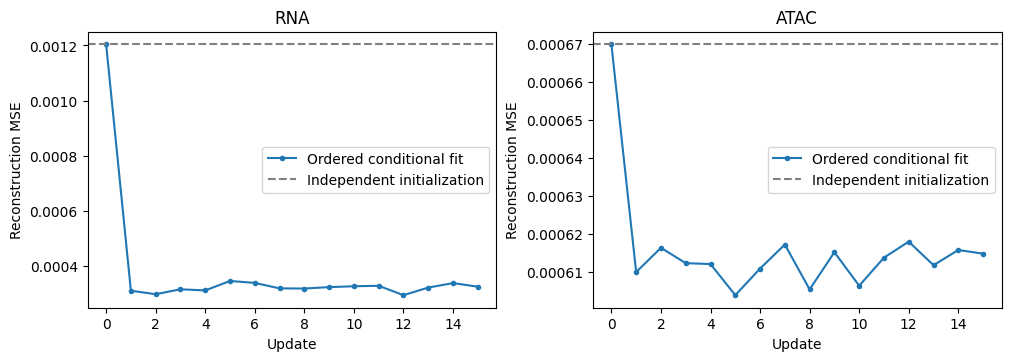

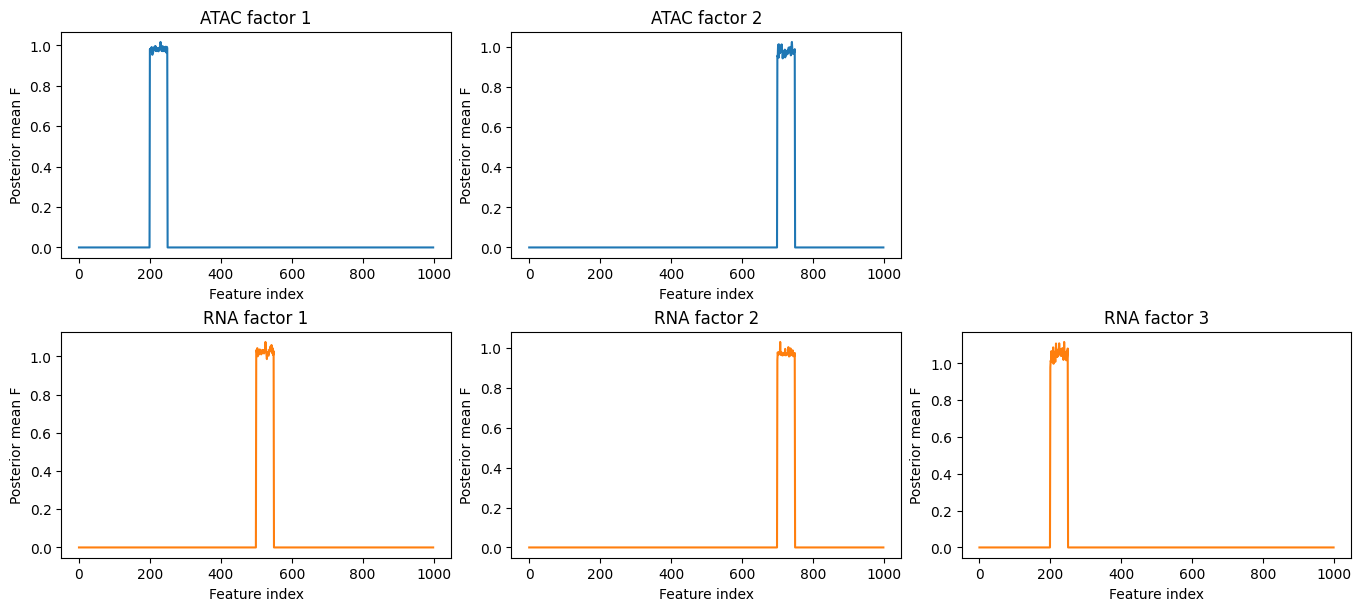

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
for ax, name, history in zip(axes, ("RNA", "ATAC"), (RNA_mse, ATAC_mse)):
    ax.plot(history, marker=".", label="Ordered conditional fit")
    ax.axhline(history[0], color="gray", linestyle="--", label="Independent initialization")
    ax.set(title=name, xlabel="Update", ylabel="Reconstruction MSE")
    ax.legend()
plt.show()

columns = max(mycebmfA.model.K, mycebmfR.model.K)
fig, axes = plt.subplots(2, columns, figsize=(4.5 * columns, 6), squeeze=False, layout="constrained")
for row, (name, model) in enumerate((("ATAC", mycebmfA), ("RNA", mycebmfR))):
    for k, ax in enumerate(axes[row]):
        if k >= model.model.K:
            ax.axis("off")
            continue
        ax.plot(model.F[:, k].detach().cpu(), color="tab:blue" if row == 0 else "tab:orange")
        ax.set(title=f"{name} factor {k + 1}", xlabel="Feature index", ylabel="Posterior mean F")
plt.show()

## Optional matched control: is ATAC information helping RNA?

This compares two RNA fits using the same initialization and training
settings. Both condition on earlier RNA loadings; one receives the fixed
independent ATAC estimates, while the other receives those estimates with
cell rows permuted. ATAC is frozen for **both** controls. Use multiple seeds
and held-out observations for broader validation; a single simulation is a
diagnostic, not evidence of a full joint inference algorithm.

Aligned ATAC RNA MSE: 0.00029255051049403846
Shuffled ATAC RNA MSE: 0.0009367172606289387


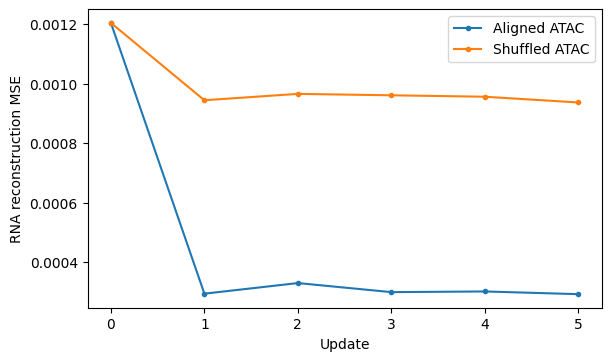

In [14]:
RUN_CONTROLS = True
CONTROL_UPDATES = 5
controls = {}

if RUN_CONTROLS:
    fixed_parents = mycebmf00A.L.detach().clone()
    permutation = torch.randperm(N, generator=torch.Generator().manual_seed(321)).to(device)
    for name, parents in (("Aligned ATAC", fixed_parents), ("Shuffled ATAC", fixed_parents[permutation])):
        torch.manual_seed(123)
        model = conditional_model(mycebmf00R, parents=parents)
        history = [reconstruction_mse(model, X_RNA)]
        for _ in range(CONTROL_UPDATES):
            with redirect_stdout(io.StringIO()):
                model.iter_once()
            history.append(reconstruction_mse(model, X_RNA))
        controls[name] = history
        print(name, "RNA MSE:", history[-1])

    fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
    for name, history in controls.items():
        ax.plot(history, marker=".", label=name)
    ax.set(xlabel="Update", ylabel="RNA reconstruction MSE")
    ax.legend()
    plt.show()

## What remains for full joint inference

For the joint prior
$$p(A,R)=\prod_k p(A_k\mid A_{<k})\prod_k p(R_k\mid R_{<k},A),$$
updating $A_k$ must include the conditional log priors of all later ATAC
loadings and all RNA loadings, averaged over their variational distributions.
Updating $R_k$ likewise includes its later RNA children. Inference therefore
allows RNA evidence to inform ATAC through these terms, even though the
generative hierarchy runs from ATAC to RNA.

The current EBNM call uses only the data likelihood and that factor's own
conditional prior, with parents replaced by posterior means. These are the
terms a future joint solver must add; repeatedly supplying the latest means
as covariates does not add them.